In [1]:
# importing all libraries needed for clustering, classification and evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set(style='whitegrid')

In [2]:
# loading the dataset and fixing column names to lowercase
df = pd.read_csv('Country-data.csv')
df.columns = [c.strip().lower() for c in df.columns]
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
# removing duplicates and converting all feature columns to numeric

df = df.drop_duplicates()

numeric_cols = [c for c in df.columns if c != 'country']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
# filling missing values with median so outliers don't affect it much
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

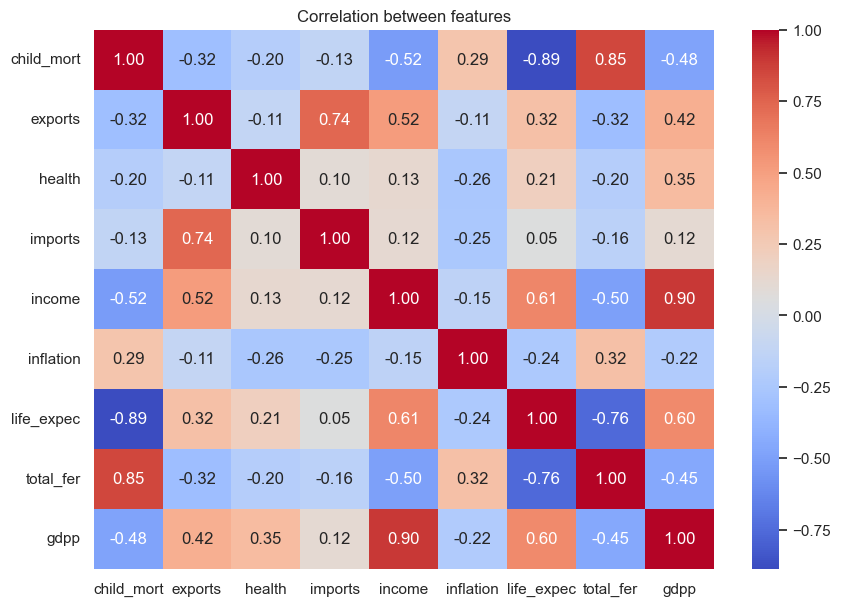

In [4]:
# checking correlation between features before clustering
plt.figure(figsize=(10,7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between features')
plt.show()

In [5]:
# scaling features since clustering algorithms are sensitive to different ranges
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

c:\Users\harsh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\harsh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\harsh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\harsh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

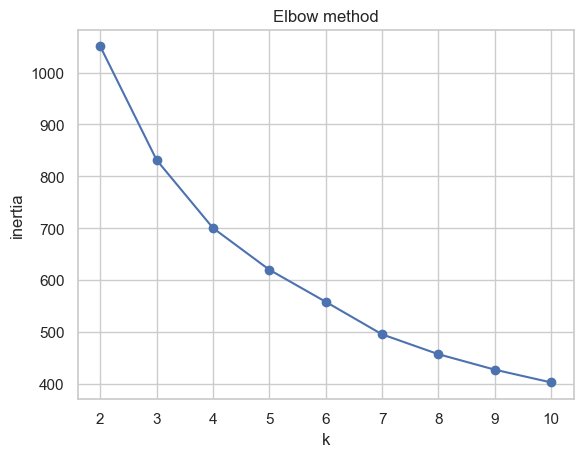

In [6]:
# using elbow method to find the right number of clusters
inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,11), inertia, marker='o')
plt.xlabel('k')
plt.ylabel('inertia')
plt.title('Elbow method')
plt.show()

In [7]:
# fitting K-Means with k=3 based on the elbow plot
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print(silhouette_score(X_scaled, df['kmeans_cluster']))
df['kmeans_cluster'].value_counts()

0.28329575683463126


c:\Users\harsh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


kmeans_cluster
2    84
1    47
0    36
Name: count, dtype: int64

In [8]:
# trying DBSCAN as a second clustering approach for comparison
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
df['dbscan_cluster'].value_counts()

dbscan_cluster
 0    137
-1     30
Name: count, dtype: int64

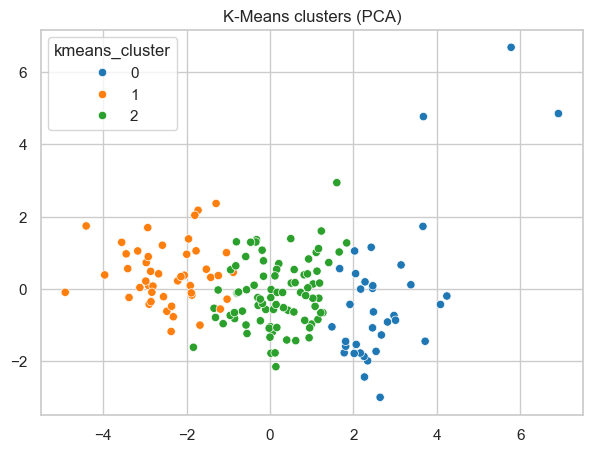

In [9]:
# reducing to 2D with PCA just to visualize the clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['kmeans_cluster'], palette='tab10')
plt.title('K-Means clusters (PCA)')
plt.show()

In [10]:
# ranking clusters by gdpp to give them meaningful labels instead of 0/1/2
cluster_rank = df.groupby('kmeans_cluster')['gdpp'].mean().sort_values().index.tolist()
labels = ['Needs Support', 'Developing', 'High Potential']
cluster_to_label = dict(zip(cluster_rank, labels))

df['segment'] = df['kmeans_cluster'].map(cluster_to_label)
df.groupby('segment')[numeric_cols].mean().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
segment,,,,,,,,,
Developing,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45
High Potential,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
Needs Support,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38


In [11]:
# splitting data to train and test the classification models
X = df[numeric_cols]
y = df['segment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((133, 9), (34, 9))

In [ ]:
# training Random Forest with GridSearchCV to find best parameters
rf_params = {'n_estimators': [100,200,300], 'max_depth': [None,4,6,8], 'min_samples_split': [2,4]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='f1_weighted', n_jobs=-1)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
print(rf_grid.best_params_, rf_grid.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300} 0.9701829309236716


In [16]:
# encoding labels since XGBoost needs numeric classes

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# training XGBoost with GridSearchCVle = LabelEncoder()
xgb_params = {'n_estimators': [100,200,300], 'max_depth': [3,4,6], 'learning_rate': [0.01,0.05,0.1]}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'), xgb_params, cv=5, scoring='f1_weighted', n_jobs=-1)
xgb_grid.fit(X_train, y_train_enc)

xgb_best = xgb_grid.best_estimator_
print(xgb_grid.best_params_, xgb_grid.best_score_)

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300} 0.9700516445854888


In [17]:
# comparing both models on the test set
rf_pred = rf_best.predict(X_test)
xgb_pred = le.inverse_transform(xgb_best.predict(X_test))

print('RF  :', accuracy_score(y_test, rf_pred), f1_score(y_test, rf_pred, average='weighted'))
print('XGB :', accuracy_score(y_test, xgb_pred), f1_score(y_test, xgb_pred, average='weighted'))

RF  : 1.0 1.0
XGB : 1.0 1.0


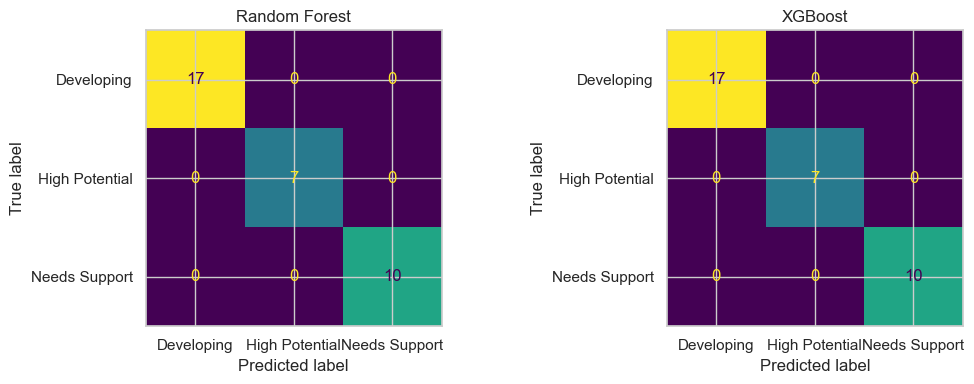

In [18]:
# plotting confusion matrix for both models side by side
fig, axes = plt.subplots(1, 2, figsize=(11,4))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=axes[0], colorbar=False)
axes[0].set_title('Random Forest')
ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred, ax=axes[1], colorbar=False)
axes[1].set_title('XGBoost')
plt.tight_layout()
plt.show()

In [19]:
# checking which features mattered most for the models
imp = pd.DataFrame({
    'feature': numeric_cols,
    'random_forest': rf_best.feature_importances_,
    'xgboost': xgb_best.feature_importances_
}).sort_values('random_forest', ascending=False)

imp

,feature,random_forest,xgboost
0,child_mort,0.244157,0.204016
6,life_expec,0.200683,0.050583
8,gdpp,0.188866,0.424819
4,income,0.172235,0.166142
7,total_fer,0.127346,0.080068
2,health,0.027656,0.007536
5,inflation,0.015402,0.020982
1,exports,0.014874,0.041031
3,imports,0.008781,0.004823


In [20]:
# listing countries that fall in the "Needs Support" segment
df[df['segment'] == 'Needs Support']['country'].tolist()

['Afghanistan',
 'Angola',
 'Benin',
 'Botswana',
 'Burkina Faso',
 'Burundi',
 'Cameroon',
 'Central African Republic',
 'Chad',
 'Comoros',
 'Congo, Dem. Rep.',
 'Congo, Rep.',
 "Cote d'Ivoire",
 'Equatorial Guinea',
 'Eritrea',
 'Gabon',
 'Gambia',
 'Ghana',
 'Guinea',
 'Guinea-Bissau',
 'Haiti',
 'Iraq',
 'Kenya',
 'Kiribati',
 'Lao',
 'Lesotho',
 'Liberia',
 'Madagascar',
 'Malawi',
 'Mali',
 'Mauritania',
 'Mozambique',
 'Namibia',
 'Niger',
 'Nigeria',
 'Pakistan',
 'Rwanda',
 'Senegal',
 'Sierra Leone',
 'South Africa',
 'Sudan',
 'Tanzania',
 'Timor-Leste',
 'Togo',
 'Uganda',
 'Yemen',
 'Zambia']